In [99]:
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [100]:
from data_load import scaled_data, raw_data, result, data_info

In [101]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [102]:
# Thickness는 모두 같은 값이므로 예측에 영향 X

print(np.sum(raw_data['Thickness 1(mm)'] != 0.7))
print(np.sum(raw_data['Thickness 2(mm)'] != 0.7))

0
0


In [103]:
# 쓸모없는 열 제외 후
raw_data_clean = raw_data.iloc[:, 6:]

split = 8470

# train, test 셋 구분
train_data = raw_data_clean.iloc[:split]
test_data = raw_data_clean.iloc[split:]

print(f'Data_columns : {train_data.columns}')
print(f'Train data : {len(train_data)}, Test data : {len(test_data)}')

Data_columns : Index(['weld force(bar)', 'weld current(kA)', 'weld Voltage(v)',
       'weld time(ms)'],
      dtype='str')
Train data : 8470, Test data : 3469


In [104]:
# 데이터 정규화

scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

train_scaled = pd.DataFrame(
    train_scaled,
    columns=train_data.columns,
    index=train_data.index
)

test_scaled = pd.DataFrame(
    test_scaled,
    columns=test_data.columns,
    index=test_data.index
)

train_scaled.head(3)

,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,-0.323611,-1.442080,-0.132275,0.433581
1,-0.303518,-1.442080,-0.132275,0.433581
2,-0.296820,-1.742859,-0.053434,-1.152371


In [105]:
features = train_scaled.columns

train_window = pd.concat(
    [
        train_scaled[features].rolling(5).max().add_suffix('_max'),
        train_scaled[features].rolling(5).min().add_suffix('_min'),
        train_scaled[features].rolling(5).mean().add_suffix('_mean'),
        train_scaled[features].rolling(5).var().add_suffix('_var')
    ],
    axis=1
).dropna().reset_index(drop=True)

test_window = pd.concat(
    [
            test_scaled[features].rolling(5).max().add_suffix('_max'),
            test_scaled[features].rolling(5).min().add_suffix('_min'),
            test_scaled[features].rolling(5).mean().add_suffix('_mean'),
            test_scaled[features].rolling(5).var().add_suffix('_var')
    ],
    axis=1
).dropna().reset_index(drop=True)

print(f'Number of features : {len(train_window.columns)}')
print(f'Columns : {train_window.columns}')
print(f'Train data : {len(train_data)}, Test data : {len(test_data)}')

Number of features : 16
Columns : Index(['weld force(bar)_max', 'weld current(kA)_max', 'weld Voltage(v)_max',
       'weld time(ms)_max', 'weld force(bar)_min', 'weld current(kA)_min',
       'weld Voltage(v)_min', 'weld time(ms)_min', 'weld force(bar)_mean',
       'weld current(kA)_mean', 'weld Voltage(v)_mean', 'weld time(ms)_mean',
       'weld force(bar)_var', 'weld current(kA)_var', 'weld Voltage(v)_var',
       'weld time(ms)_var'],
      dtype='str')
Train data : 8470, Test data : 3469


In [106]:
# Isolatoin tree로 이상치 발견

model = IsolationForest(contamination=0.0035, random_state=42)

model.fit(train_window)

predictions = model.predict(train_window)


In [107]:
# 이상치 군집화

idx = (predictions == -1)

X = train_window.loc[idx, :].copy() 

gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X)
labels = gmm.predict(X)

X['cluster'] = labels

X.head()

,weld force(bar)_max,weld current(kA)_max,weld Voltage(v)_max,weld time(ms)_max,weld force(bar)_min,weld current(kA)_min,weld Voltage(v)_min,weld time(ms)_min,weld force(bar)_mean,weld current(kA)_mean,weld Voltage(v)_mean,weld time(ms)_mean,weld force(bar)_var,weld current(kA)_var,weld Voltage(v)_var,weld time(ms)_var,cluster
1873,5.17535,0.362592,-6.400140,2.019532,-0.216445,0.162072,-9.001895,-1.152371,0.861914,0.262332,-7.882352,0.116390,5.814292,0.010052,1.837269,1.760669,0
1874,5.17535,0.462851,-6.400140,0.433581,-0.216445,0.162072,-9.001895,-1.152371,1.940273,0.302436,-8.402703,-0.200800,8.721438,0.018094,1.262918,0.754572,0
1875,5.17535,0.462851,-8.804792,0.433581,-0.216445,0.162072,-9.080736,-1.152371,2.848506,0.362592,-8.938822,0.116390,7.948867,0.015078,0.016006,0.503048,0
1876,5.17535,0.663370,-8.804792,0.433581,-0.216445,0.362592,-9.080736,0.433581,3.756739,0.462851,-8.994011,0.433581,5.114078,0.015078,0.012743,0.000000,2
1877,5.17535,0.663370,-9.001895,0.433581,4.190762,0.362592,-9.317259,0.433581,4.638180,0.523007,-9.096504,0.433581,0.243451,0.018094,0.016783,0.000000,1


In [108]:
# 군집화 결과 비교
split = result['working time'].searchsorted(pd.Timestamp('2020-04-02'))

undercut_idx = result.iloc[:split]['defect type'] == 1
lack_idx = result.iloc[:split]['defect type'] == 2
crack_idx = result.iloc[:split]['defect type'] == 3


anomaly1_cnt = np.sum(labels == 0)
anomaly2_cnt = np.sum(labels == 1) 
anomaly3_cnt = np.sum(labels == 2) 
print(f'이상치 분류 갯수 : {anomaly1_cnt}, {anomaly2_cnt}, {anomaly3_cnt}\n')

defect = pd.Series(result.iloc[:split]['defect'], dtype=int)
print(f'실제 이상치 갯수 : {np.sum(defect[undercut_idx])},', 
      f'{np.sum(defect[crack_idx])}, {np.sum(defect[lack_idx])}')

이상치 분류 갯수 : 9, 18, 3

실제 이상치 갯수 : 11, 7, 10


In [109]:
anomaly1 = X.loc[X['cluster'] == 0, :]
anomaly2 = X.loc[X['cluster'] == 1, :]
anomaly3 = X.loc[X['cluster'] == 2, :]

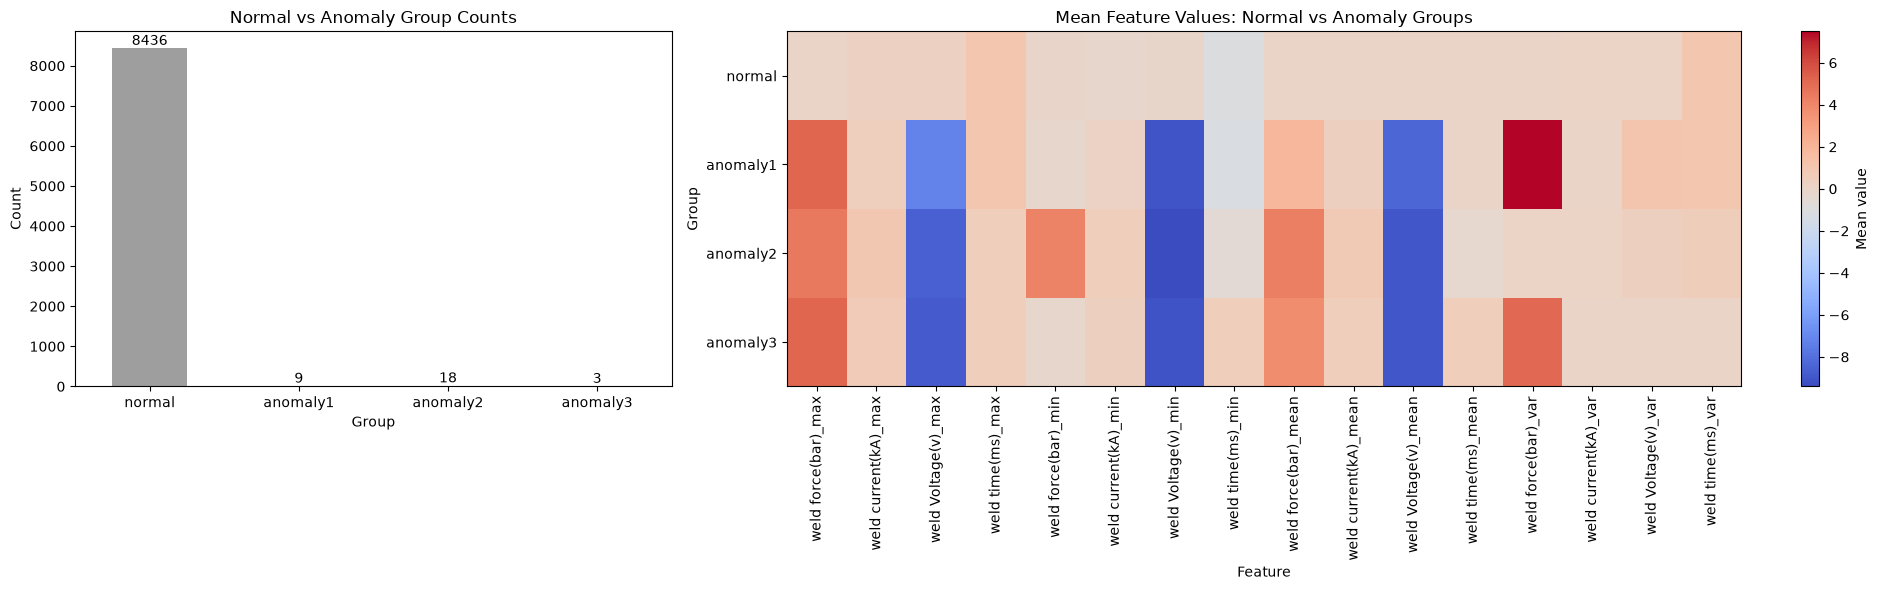

,normal,anomaly1,anomaly2,anomaly3
weld force(bar)_max,0.018,5.175,4.514,5.175
weld current(kA)_max,0.198,0.429,0.947,0.663
weld Voltage(v)_max,0.177,-7.202,-8.555,-8.805
weld time(ms)_max,1.012,0.962,0.434,0.434
weld force(bar)_min,-0.039,-0.216,4.161,-0.216
weld current(kA)_min,-0.192,0.162,0.446,0.363
weld Voltage(v)_min,-0.121,-9.028,-9.403,-9.081
weld time(ms)_min,-1.024,-1.152,-0.624,0.434
weld force(bar)_mean,-0.012,1.884,4.290,3.757
weld current(kA)_mean,-0.002,0.309,0.720,0.463


In [110]:
# Isolation Forest에서 정상으로 판정된 데이터
normal_data = train_window.loc[predictions == 1, :]

comparison_groups = {
    'normal': normal_data,
    'anomaly1': anomaly1,
    'anomaly2': anomaly2,
    'anomaly3': anomaly3,
}

# 정상 데이터와 anomaly 그룹별 데이터 개수 비교
counts = pd.Series({name: len(group) for name, group in comparison_groups.items()})

fig, axes = plt.subplots(1, 2, figsize=(20, 6), gridspec_kw={'width_ratios': [1, 2]})

counts.plot(kind='bar', ax=axes[0], color=['#9E9E9E', '#4C78A8', '#F58518', '#54A24B'])
axes[0].set_title('Normal vs Anomaly Group Counts')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for index, value in enumerate(counts):
    axes[0].text(index, value, str(value), ha='center', va='bottom')

# 정상 데이터와 anomaly 그룹의 변수별 평균값 비교
mean_values = pd.DataFrame({name: group.drop(columns='cluster', errors='ignore').mean()
                            for name, group in comparison_groups.items()})
mean_values = mean_values.select_dtypes(include='number')

image = axes[1].imshow(mean_values.T, aspect='auto', cmap='coolwarm')
axes[1].set_title('Mean Feature Values: Normal vs Anomaly Groups')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Group')
axes[1].set_xticks(range(len(mean_values.index)))
axes[1].set_xticklabels(mean_values.index, rotation=90)
axes[1].set_yticks(range(len(mean_values.columns)))
axes[1].set_yticklabels(mean_values.columns)
fig.colorbar(image, ax=axes[1], label='Mean value')

plt.tight_layout()
plt.show()

mean_values.round(3)
